
# 🏠 House Price Prediction & Classification
An end-to-end Machine Learning project using the Ames Housing dataset.
## Tasks
- Predict house prices using Linear Regression.
- Classify houses as Affordable or Expensive using Logistic Regression.
- Classify houses using K-Nearest Neighbors (KNN).
The project uses the full set of available explanatory features and demonstrates a complete Machine Learning workflow.

## 1. Import Libraries
We begin by importing the libraries needed for data analysis, preprocessing, visualization, machine learning, and evaluation.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib
from pathlib import Path

## 2. Load the Dataset
We load the Kaggle training dataset into a pandas DataFrame.
Each row represents a house and each column describes one property characteristic.


In [3]:
train_df = pd.read_csv("../data/train.csv")

## 3. Understand the Dataset

In [4]:
print("Train shape:", train_df.shape)

Train shape: (1460, 81)


In [5]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
missing_values = train_df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0].head(40)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## 4. Explore the Target Variable
`SalePrice` is the target for the regression task.
We visualize its distribution to understand how house prices are distributed.

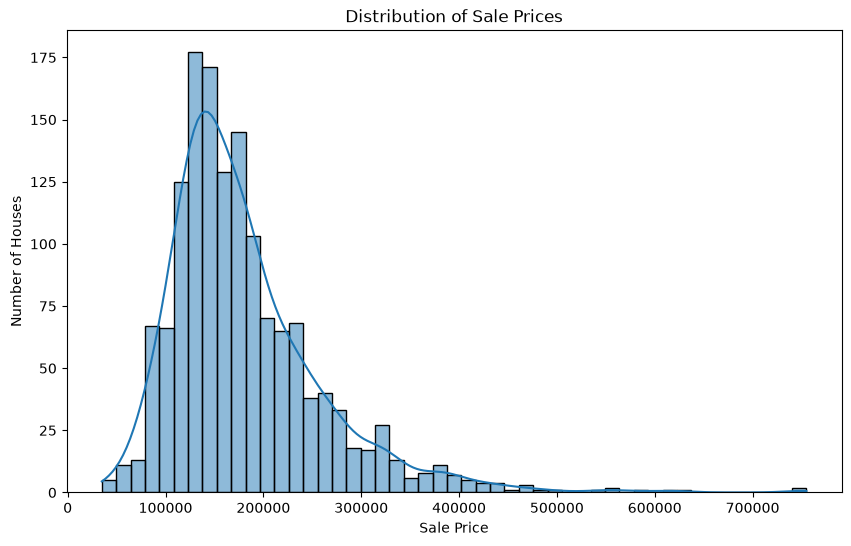

In [8]:

plt.figure(figsize=(10, 6)) 
sns.histplot(train_df["SalePrice"],kde=True)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.show()

## 5. Separate Features from the Target
For regression:
- `X` contains the house features.
- `y` contains `SalePrice`.
We remove `SalePrice` from `X` because it is the answer we want the model to predict.
We also remove `Id` because it is an identifier, not a meaningful house characteristic.

In [9]:

X = train_df.drop(columns=["SalePrice", "Id"])
y = train_df["SalePrice"]
print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])


Number of features: 79
Number of samples: 1460


## 6. Identify Numerical and Categorical Features
Machine Learning models need numerical input.
Our dataset contains both:
- Numerical features.
- Categorical features.

We will process each type differently.

In [10]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numeric_features))

Categorical features: 43
Numerical features: 36


C:\Users\HP User\AppData\Local\Temp\ipykernel_10212\4150127259.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(



## 7. Split the Regression Data
We divide the data into:
- 80% training data
- 20% testing data
The model learns only from the training data.
The test set is kept unseen until evaluation.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1168
Testing samples: 292



## 8. Preprocess Numerical Features
For numerical columns:
1. Replace missing values using the median.
2. Standardize the values using `StandardScaler`.
The preprocessing is placed inside a pipeline so that the statistics are learned only from the training data.

In [12]:
numeric_pipeline = Pipeline(
    steps=[("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())]
)

## 9. Preprocess Categorical Features
Categorical values such as `Neighborhood = CollgCr` cannot be directly used by most ML models.
We will:
1. Replace missing categorical values with the most frequent value.
2. Convert categories into numerical columns using One-Hot Encoding.
`handle_unknown="ignore"` prevents errors when a category appears in the test set that was not present during training.


In [13]:
categorical_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(handle_unknown="ignore"))]
)

## 10. Combine Numerical and Categorical Preprocessing
`ColumnTransformer` allows us to apply different preprocessing steps to different groups of columns.
Numerical columns use the numerical pipeline.
Categorical columns use the categorical pipeline.

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",numeric_pipeline,numeric_features),
        ("cat",categorical_pipeline,categorical_features)
    ]
)

# Part A — Regression
## 10. Build the Linear Regression Pipeline
Linear Regression predicts a continuous numerical value.
Here, the target is `SalePrice`.
The pipeline performs:
Raw features
→ preprocessing
→ Linear Regression
→ predicted price

In [15]:
linear_model=Pipeline(
    steps=[("preprocessor",preprocessor),
           ("model",LinearRegression())]
)

## 11. Train the Linear Regression Model
The `fit()` method teaches the model the relationship between the house features and their sale prices.
All preprocessing is learned from the training set inside the pipeline.

In [16]:
linear_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](79,)","['MSSubClass','MSZoning','LotFrontage',...,'YrSold','SaleType', 'SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,79
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset o

## 12. Predict House Prices
Now we use the trained model to predict prices for houses in the test split.
These houses were not used to train the model.

In [17]:
y_pred =linear_model.predict(X_test)

## 13. Evaluate the Regression Model
We use three metrics:
### MAE
Average absolute prediction error.
### RMSE
Penalizes large errors more strongly than MAE.
### R²
Measures how much variation in the target is explained by the model.
For MAE and RMSE, lower is better.
For R², higher is better.

In [18]:
mae =mean_absolute_error(y_test,y_pred)
rmse =np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
print(f"MAE : ${mae}")
print(f"RMSE : ${rmse}")
print(f"R²  : {r2}")

MAE : $18287.69862268414
RMSE : $29473.873055291337
R²  : 0.8867441658393297


## 14. Actual vs Predicted Prices
A useful visualization for regression is an Actual-vs-Predicted plot.
If predictions are accurate, points should be relatively close to the diagonal relationship between actual and predicted values.

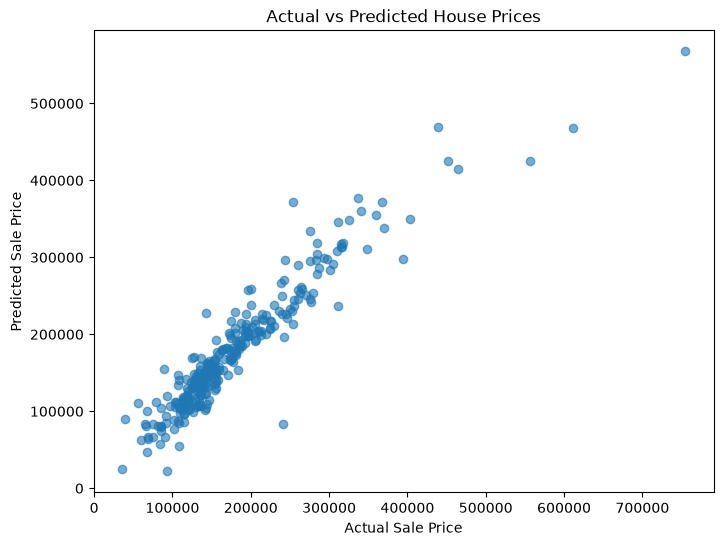

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.6)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Part B — Classification
## 15. Create the House Category
The original target is a continuous price.
For classification, we create a binary target:
- `0` → Affordable
- `1` → Expensive
We use the median `SalePrice` as the boundary.
Important:
`SalePrice` is used only to create the label and will not be included as an input feature.

In [20]:
price_threshold = train_df["SalePrice"].median()
train_df["PriceCategory"] = (train_df["SalePrice"]>price_threshold).astype(int)
print(train_df["PriceCategory"].value_counts())

PriceCategory
0    732
1    728
Name: count, dtype: int64



## 16. Prepare the Classification Dataset
For classification:
- `X_class` contains all 79 explanatory features except `Id`.
- `y_class` contains the new Affordable/Expensive label.
We still use all available house features.

In [21]:
X_class=train_df.drop(columns=["SalePrice", "Id", "PriceCategory"])
y_class=train_df["PriceCategory"]
numeric_features_class=X_class.select_dtypes(
    include=["int64", "float64"]).columns.tolist()
categorical_features_class=X_class.select_dtypes(
    include=["object"]).columns.tolist()


C:\Users\HP User\AppData\Local\Temp\ipykernel_10212\300464657.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_class=X_class.select_dtypes(


## 17. Split the Classification Data
We again create training and testing sets.
`stratify=y_class` keeps the proportion of Affordable and Expensive houses similar in both sets.

In [22]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.20, random_state=42)

## 18. Build the Classification Preprocessor
We create the same type of preprocessing:
- Numerical → median imputation + scaling.
- Categorical → most-frequent imputation + one-hot encoding.
This preprocessing will be shared by Logistic Regression and KNN.

In [23]:
numeric_pipeline_class = Pipeline(
    steps=[("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())]
)
categorical_pipeline_class = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(handle_unknown="ignore"))]
)
preprocessor_class = ColumnTransformer(
    transformers=[
        ("num",numeric_pipeline_class,numeric_features_class),
        ("cat",categorical_pipeline_class,categorical_features_class)
    ]
)

## 19. Train Logistic Regression
Logistic Regression is a classification algorithm.
It estimates the probability that a house belongs to class 1.
Here:
- 0 = Affordable
- 1 = Expensive

In [24]:

logistic_model = Pipeline(steps=[("preprocessor",preprocessor_class),                             
    ("model",LogisticRegression(max_iter=2000,random_state=42))]
)
logistic_model.fit(X_train_class,y_train_class)
  

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](79,)","['MSSubClass','MSZoning','LotFrontage',...,'YrSold','SaleType', 'SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,79
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

## 20. Predict House Categories
We use the trained Logistic Regression model to classify unseen houses.
The output is either:
- `0` → Affordable
- `1` → Expensive

In [25]:
y_pred_class = logistic_model.predict(X_test_class)


## 21. Evaluate Logistic Regression
We evaluate the classifier using:
- Accuracy
- Precision
- Recall
- F1 Score
Using several metrics is better than relying only on accuracy.

In [26]:
class_accuracy = accuracy_score(y_test_class, y_pred_class)
print("Class accuracy:", class_accuracy)
class_precision = precision_score(y_test_class, y_pred_class)
print("Class precision:", class_precision)
class_recall = recall_score(y_test_class, y_pred_class)
print("Class recall:", class_recall)
class_f1 = f1_score(y_test_class, y_pred_class)
print("Class F1 score:", class_f1)

Class accuracy: 0.958904109589041
Class precision: 0.9280575539568345
Class recall: 0.9847328244274809
Class F1 score: 0.9555555555555556



## 22. Confusion Matrix
The confusion matrix shows the types of correct and incorrect predictions.
For our problem:
- True Negative → correctly predicted Affordable.
- False Positive → Affordable predicted as Expensive.
- False Negative → Expensive predicted as Affordable.
- True Positive → correctly predicted Expensive.

Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

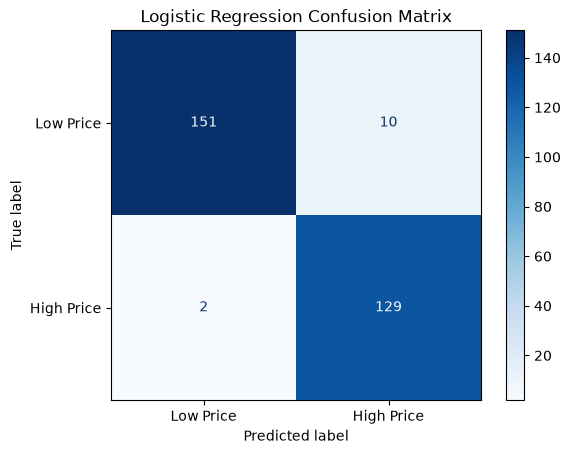

In [27]:
cm=confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low Price", "High Price"])
disp.plot(cmap=plt.cm.Blues)

plt.title("Logistic Regression Confusion Matrix")

# Part C — K-Nearest Neighbors
## 23. Train KNN
KNN predicts a class by looking at the nearest training examples.
KNN depends on distances, feature scaling is particularly important.

In [28]:
knn_model=Pipeline(steps=[("preprocessor",preprocessor_class),
    ("model",KNeighborsClassifier(n_neighbors=5))]
)
knn_model.fit(X_train_class,y_train_class)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](79,)","['MSSubClass','MSZoning','LotFrontage',...,'YrSold','SaleType', 'SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,79
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

## 24. Predict Using KNN
We use the trained KNN model to classify the test houses.

In [29]:
y_pred_knn = knn_model.predict(X_test_class)

## 25. Evaluate KNN
We use the same evaluation metrics as Logistic Regression so the two models can be compared fairly.

In [30]:
knn_accuracy = accuracy_score(y_test_class, y_pred_knn)
print("KNN accuracy:", knn_accuracy)
knn_precision = precision_score(y_test_class, y_pred_knn)
print("KNN precision:", knn_precision)
knn_recall = recall_score(y_test_class, y_pred_knn)
print("KNN recall:", knn_recall)
knn_f1 = f1_score(y_test_class, y_pred_knn)
print("KNN F1 score:", knn_f1)

KNN accuracy: 0.928082191780822
KNN precision: 0.9230769230769231
KNN recall: 0.916030534351145
KNN F1 score: 0.9195402298850575


## 25. Compare the Classification Models
We compare Logistic Regression and KNN using the same test set and metrics.
This lets us determine which model performs better for this particular classification task.

In [31]:
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [class_accuracy, knn_accuracy],
    "Precision": [class_precision, knn_precision],
    "Recall": [class_recall, knn_recall],
    "F1 Score": [class_f1, knn_f1]
})
classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.958904,0.928058,0.984733,0.955556
1,KNN,0.928082,0.923077,0.916031,0.919540


## 26. Visual Model Comparison
A bar chart makes it easier to compare the classification metrics visually.

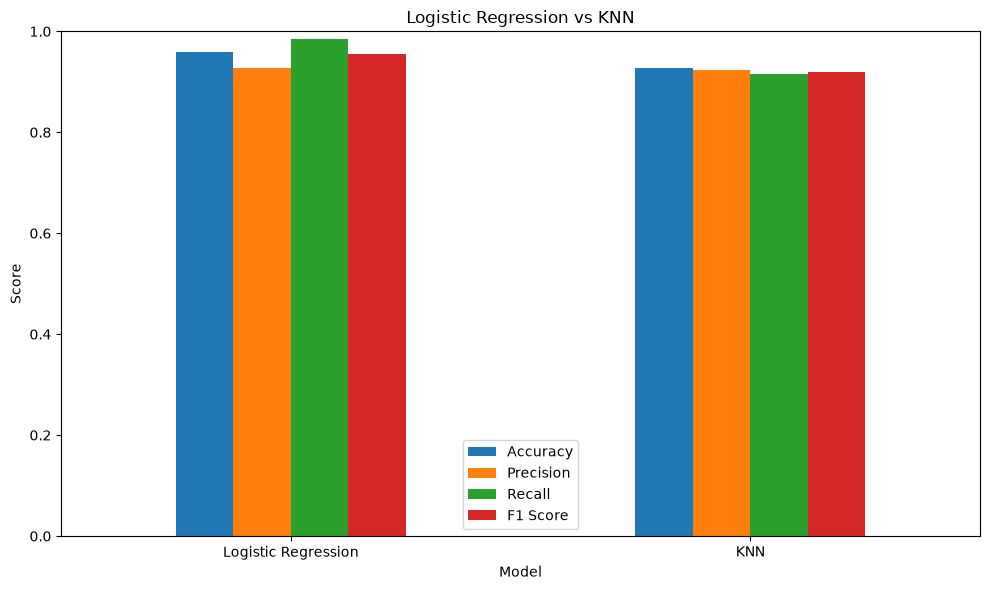

In [33]:
classification_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(10, 6),ylim=(0, 1))
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Logistic Regression vs KNN")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 27. Experiment with Different K Values
`k` is a hyperparameter of KNN.
A small k can make the model sensitive to individual training examples.
A larger k creates smoother decisions.
We will test several values and compare their F1 scores.

In [36]:
k_values=list(range(1, 21,2))
knn_results = []
for k in k_values:
    knn_model_k = Pipeline(steps=[("preprocessor", preprocessor_class),
                                   ("model", KNeighborsClassifier(n_neighbors=k))])
    knn_model_k.fit(X_train_class, y_train_class)
    y_pred_knn_k = knn_model_k.predict(X_test_class)
    knn_f1_k = f1_score(y_test_class, y_pred_knn_k)
    knn_results.append({"k":k, "f1_score": knn_f1_k})

knn_results

[{'k': 1, 'f1_score': 0.9328358208955224},
 {'k': 3, 'f1_score': 0.9277566539923955},
 {'k': 5, 'f1_score': 0.9195402298850575},
 {'k': 7, 'f1_score': 0.9307692307692308},
 {'k': 9, 'f1_score': 0.9272030651340997},
 {'k': 11, 'f1_score': 0.918918918918919},
 {'k': 13, 'f1_score': 0.9111969111969112},
 {'k': 15, 'f1_score': 0.9027237354085603},
 {'k': 17, 'f1_score': 0.8992248062015504},
 {'k': 19, 'f1_score': 0.9}]

## 28. Visualize KNN Hyperparameter Performance
We visualize how F1 changes as k changes.
This is a simple example of hyperparameter experimentation.

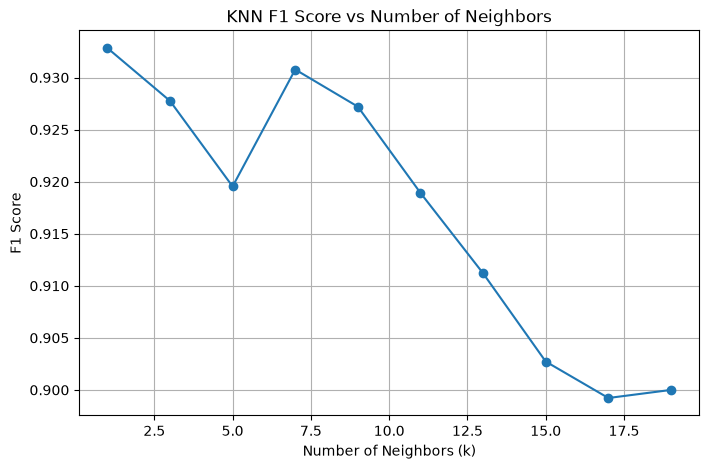

In [38]:
plt.figure(figsize=(8, 5))
knn_results_df = pd.DataFrame(knn_results)
plt.plot(knn_results_df["k"], knn_results_df["f1_score"], marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("F1 Score")
plt.title("KNN F1 Score vs Number of Neighbors")
plt.grid(True)
plt.show()

## 29. Save the Models
We can save trained pipelines using `joblib`.
Saving the complete pipeline because it includes both preprocessing and the model.
This means we can later load the pipeline and pass raw feature values to it.

In [39]:
Path("../models").mkdir(exist_ok=True)
joblib.dump(linear_model,"../models/linear_regression_full_features.joblib")
joblib.dump(logistic_model,"../models/logistic_regression_full_features.joblib")
joblib.dump(knn_model,"../models/knn_full_features.joblib")

['../models/knn_full_features.joblib']